# Task 04 - Part B: Machine Learning Model Comparison

This part focuses on building and comparing different regression models using an engineered dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving HistoricalQuotes.csv to HistoricalQuotes.csv


In [ ]:
# Load the uploaded dataset
df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (2518, 6)

Columns:
['Date', ' Close/Last', ' Volume', ' Open', ' High', ' Low']

First 5 rows:


,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Convert Close/Last to numeric
df["Close/Last"] = (
    df["Close/Last"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Sort by date
df = df.sort_values("Date")

print("Data cleaned successfully!")
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Data cleaned successfully!

Data types:
Date          datetime64[ns]
Close/Last           float64
Volume                 int64
Open                  object
High                  object
Low                   object
dtype: object

Missing values:
Date          0
Close/Last    0
Volume        0
Open          0
High          0
Low           0
dtype: int64


In [ ]:
# Select features and target
X = df[["Volume", "Open", "High", "Low"]]
y = df["Close/Last"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
         Volume       Open       High        Low
2517  137312041   $29.3928   $29.9286     $29.35
2516  141486282     $29.99   $30.1186   $29.6771
2515   92846488   $29.8486   $29.9814   $29.7057
2514   89591907   $29.8971   $30.1314   $29.8043
2513  224647427   $30.7057   $31.3857   $30.6614

Target:
2517    29.8557
2516    29.8357
2515    29.9043
2514    30.1014
2513    31.2786
Name: Close/Last, dtype: float64

Feature shape: (2518, 4)
Target shape: (2518,)


In [ ]:
# Convert all price columns to numeric

price_columns = ["Close/Last", "Open", "High", "Low"]

for column in price_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

# Make sure Volume is numeric
df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce")

print("All numeric columns converted successfully!")

print("\nData types:")
print(df[["Close/Last", "Volume", "Open", "High", "Low"]].dtypes)

All numeric columns converted successfully!

Data types:
Close/Last    float64
Volume          int64
Open          float64
High          float64
Low           float64
dtype: object


In [ ]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2014, 4)
Testing data: (504, 4)


In [ ]:
# Select features and target again

X = df[["Volume", "Open", "High", "Low"]]
y = df["Close/Last"]

print("Features and target prepared successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

Features and target prepared successfully!
X shape: (2518, 4)
y shape: (2518,)


,Volume,Open,High,Low
2517,137312041,29.3928,29.9286,29.3500
2516,141486282,29.9900,30.1186,29.6771
2515,92846488,29.8486,29.9814,29.7057
2514,89591907,29.8971,30.1314,29.8043
2513,224647427,30.7057,31.3857,30.6614


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

In [ ]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

print("===== MODEL COMPARISON =====")
display(results_df)

===== MODEL COMPARISON =====


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.449274,0.686581,0.999855
1,Ridge Regression,0.449340,0.686627,0.999855
2,Decision Tree,0.861955,1.424177,0.999377
3,Random Forest,0.653274,1.008572,0.999688


In [19]:
# 5-Fold Cross-Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    cv_results.append({
        "Model": name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

print("===== 5-FOLD CROSS-VALIDATION =====")
display(cv_df)

===== 5-FOLD CROSS-VALIDATION =====


,Model,Mean CV R2,Std CV R2
0,Linear Regression,0.999865,0.000015
1,Ridge Regression,0.999865,0.000015
2,Decision Tree,0.999515,0.000073
3,Random Forest,0.999718,0.000036


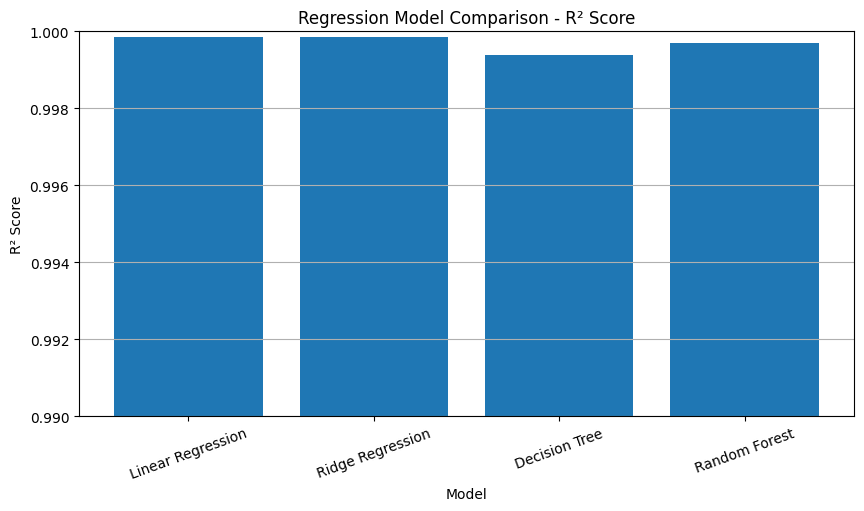

In [20]:
# Model Performance Comparison

plt.figure(figsize=(10, 5))

plt.bar(results_df["Model"], results_df["R2 Score"])

plt.title("Regression Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.ylim(0.99, 1.00)
plt.grid(axis="y")

plt.show()

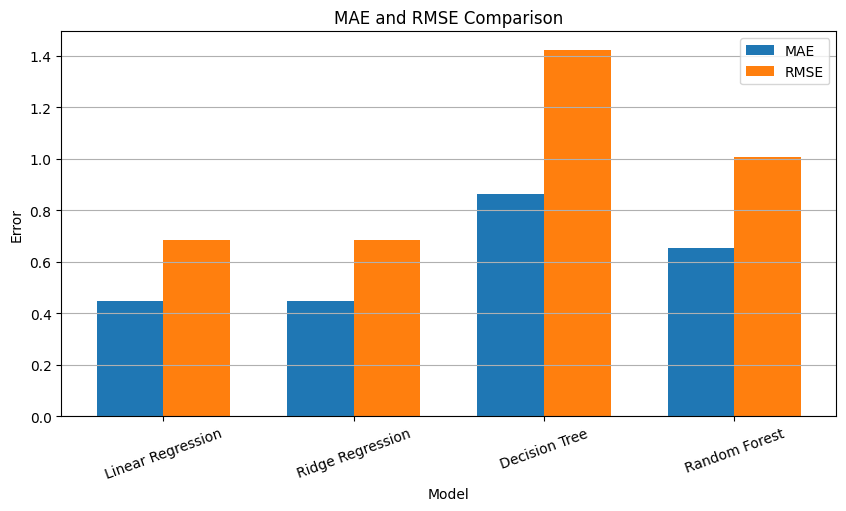

In [21]:
# MAE and RMSE Comparison

x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, results_df["MAE"], width, label="MAE")
plt.bar(x + width/2, results_df["RMSE"], width, label="RMSE")

plt.title("MAE and RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(x, results_df["Model"], rotation=20)
plt.legend()
plt.grid(axis="y")

plt.show()

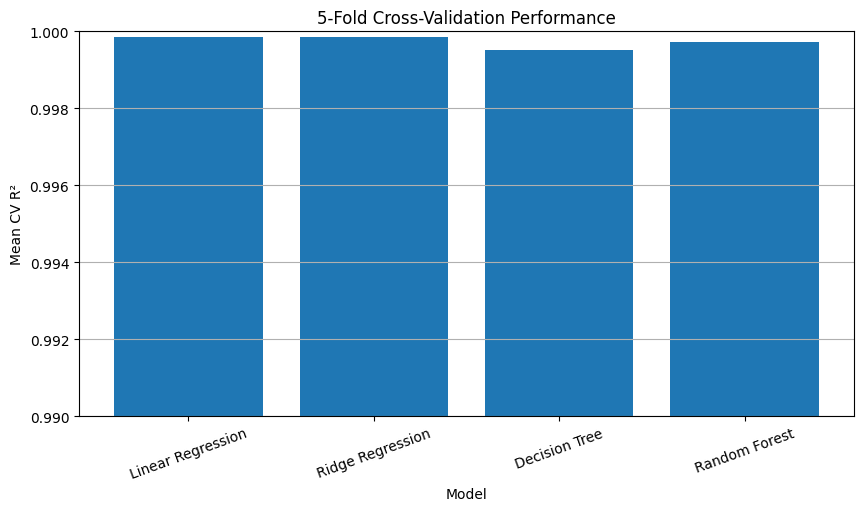

In [22]:
# Cross-Validation Performance

plt.figure(figsize=(10, 5))

plt.bar(
    cv_df["Model"],
    cv_df["Mean CV R2"]
)

plt.title("5-Fold Cross-Validation Performance")
plt.xlabel("Model")
plt.ylabel("Mean CV R²")
plt.xticks(rotation=20)
plt.ylim(0.99, 1.00)
plt.grid(axis="y")

plt.show()

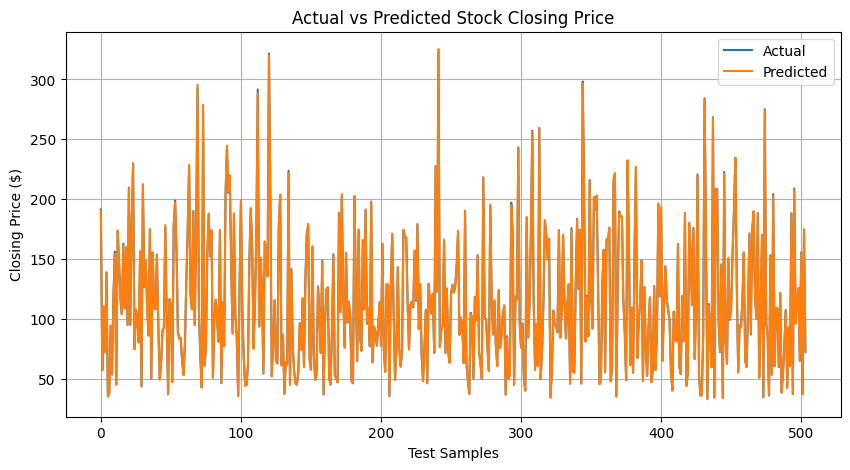

In [23]:
# Actual vs Predicted Values

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Predicted"
)

plt.title("Actual vs Predicted Stock Closing Price")
plt.xlabel("Test Samples")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)

plt.show()

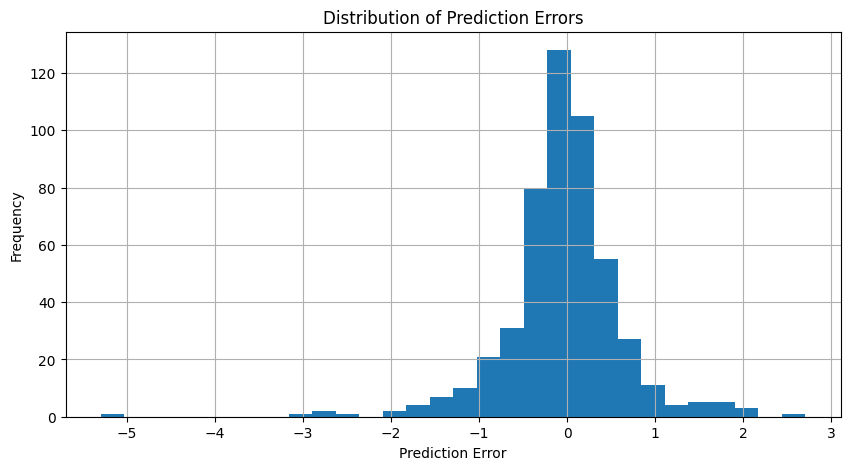

In [24]:
# Prediction Error

errors = y_test.values - y_pred

plt.figure(figsize=(10, 5))

plt.hist(errors, bins=30)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

# Conclusion

In Part B, different machine learning regression models were trained and evaluated for predicting stock closing prices.

The models used were:

- Linear Regression
- Ridge Regression
- Decision Tree Regression
- Random Forest Regression

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. Five-fold cross-validation was also performed to evaluate model consistency.

The results showed very high R² values across all models. Linear Regression and Ridge Regression achieved approximately 0.999855 R² on the test set, while their mean cross-validation R² was approximately 0.999865.

The prediction results were visualized using an Actual vs Predicted graph, and the distribution of prediction errors was also analyzed.

## Key Learning Outcomes

- Prepared numerical features for machine learning
- Split data into training and testing sets
- Built multiple regression models
- Evaluated models using MAE, RMSE, and R²
- Applied 5-fold cross-validation
- Compared regression model performance
- Visualized actual and predicted values
- Analyzed prediction errors